<a href="https://colab.research.google.com/github/Pratyusha1618O/Machine-Learning/blob/main/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
from google.colab import drive

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
root_dir = '/content'
os.chdir(root_dir)

In [6]:
df = pd.read_csv("temperatures-selected-columns.csv")

In [7]:
df.head();

In [8]:
df.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   YEAR    117 non-null    int64  
 1   JAN     117 non-null    float64
 2   FEB     117 non-null    float64
 3   MAR     117 non-null    float64
 4   APR     117 non-null    float64
 5   MAY     117 non-null    float64
 6   JUN     117 non-null    float64
 7   JUL     117 non-null    float64
 8   AUG     117 non-null    float64
 9   SEP     117 non-null    float64
dtypes: float64(9), int64(1)
memory usage: 9.3 KB


In [9]:
df.describe();

In [10]:
print(df.columns);

Index(['YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP'], dtype='object')


In [12]:
print(df.columns.tolist())

['YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP']


In [13]:
months = df.columns[1:]   # All columns except YEAR

month_data = []

for month in months:
    for temp in df[month]:
        month_data.append([month, temp])

new_df = pd.DataFrame(month_data, columns=['Month', 'Temperature'])

new_df.head()


,Month,Temperature
0,JAN,22.40
1,JAN,24.93
2,JAN,23.44
3,JAN,22.50
4,JAN,22.00


In [14]:
month_mapping = {
    'JAN': 1,
    'FEB': 2,
    'MAR': 3,
    'APR': 4,
    'MAY': 5,
    'JUN': 6,
    'JUL': 7,
    'AUG': 8,
    'SEP': 9
}

new_df['Month'] = new_df['Month'].map(month_mapping)

In [15]:
df.shape

(117, 10)

In [16]:
X = new_df[['Month']]
y = new_df['Temperature']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R² Score:", r2)

Mean Squared Error (MSE): 6.541988168768104
Mean Absolute Error (MAE): 2.252611172119756
R² Score: 0.42892330893133723


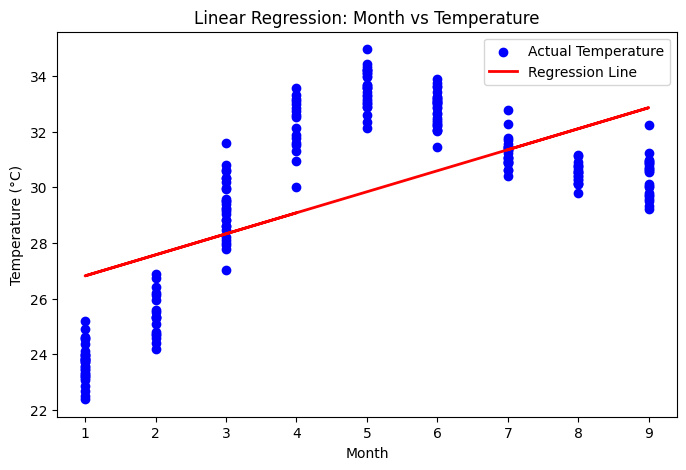

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test, color='blue', label='Actual Temperature')

plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("Linear Regression: Month vs Temperature")
plt.legend()

plt.show()

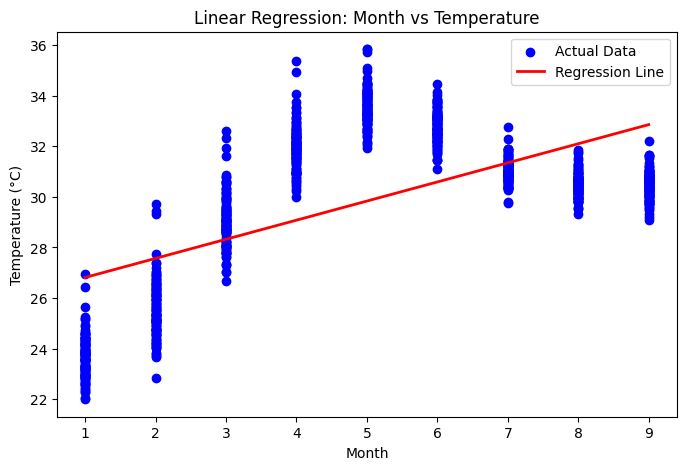

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, color='blue', label='Actual Data')

X_sorted = X.sort_values(by='Month')
y_pred_sorted = model.predict(X_sorted)

plt.plot(X_sorted, y_pred_sorted, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("Linear Regression: Month vs Temperature")
plt.legend()

plt.show()

In [23]:
import pandas as pd

months = pd.DataFrame({'Month': range(1, 10)})

predicted = model.predict(months)

for month, temp in zip(months['Month'], predicted):
    print(f"Month {month}: {temp:.2f} °C")

Month 1: 26.81 °C
Month 2: 27.57 °C
Month 3: 28.32 °C
Month 4: 29.08 °C
Month 5: 29.84 °C
Month 6: 30.59 °C
Month 7: 31.35 °C
Month 8: 32.10 °C
Month 9: 32.86 °C
